In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
from ultralytics import YOLO

In [3]:
# Define the root directory of the project
ROOT_DIR = Path.cwd().parent

In [4]:
# Load the YOLO model for document segmentation
model = YOLO(ROOT_DIR /"local_models/doc_seg/last.onnx", task="segment")

In [5]:
def plot_seg_result(result, details: bool = True) -> None:
    """Plot the segmentation results."""
    if details:
        boxes = result.boxes  # Boxes object for bbox outputs
        masks = result.masks  # Masks object for segmentation masks outputs
        keypoints = result.keypoints  # Keypoints object for pose outputs
        probs = result.probs  # Probs object for classification outputs
        xy = result.masks.xy  # mask polygons in pixel coordinates
        xyn = result.masks.xyn  # normalized mask polygons
        masks = result.masks.data  # binary masks, shape (N,H,W), dtype torch.uint8
        print(f"Boxes: {boxes}, Masks: {masks}, Keypoints: {keypoints}, Probs: {probs}, XY: {xy}, XYN: {xyn}")
    im_bgr = result.plot()
    im_rgb = im_bgr[..., ::-1]

    plt.figure(figsize=(10, 10))
    plt.imshow(im_rgb)
    plt.axis('off')  # Hide axes ticks
    plt.show()

Processing image: /Users/son/Documents/my_ORC/Receipt_Understanding/sample_data/doc_seg/seg_2.jpg

image 1/1 /Users/son/Documents/my_ORC/Receipt_Understanding/sample_data/doc_seg/seg_2.jpg: 640x640 1 receipt, 62.2ms
Speed: 2.9ms preprocess, 62.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
1 results found


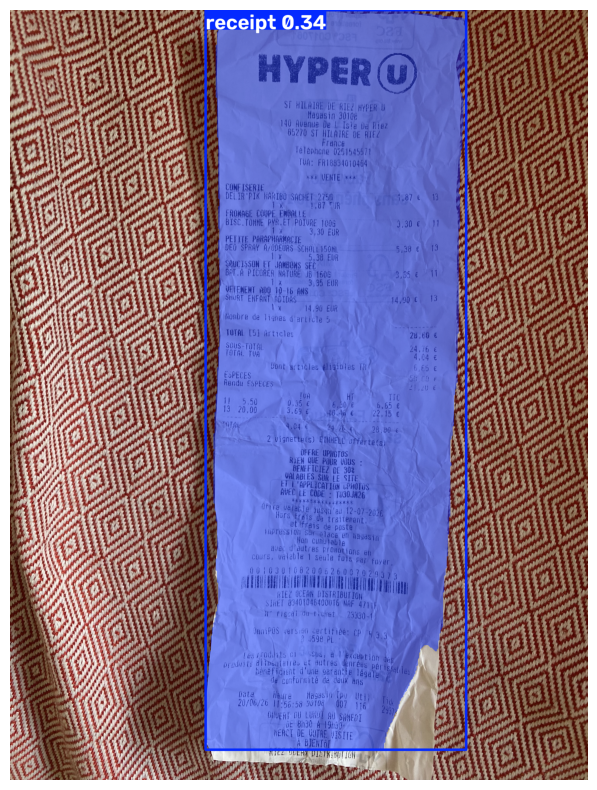

Processing image: /Users/son/Documents/my_ORC/Receipt_Understanding/sample_data/doc_seg/seg_3.jpg

image 1/1 /Users/son/Documents/my_ORC/Receipt_Understanding/sample_data/doc_seg/seg_3.jpg: 640x640 1 receipt, 59.1ms
Speed: 2.8ms preprocess, 59.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)
1 results found


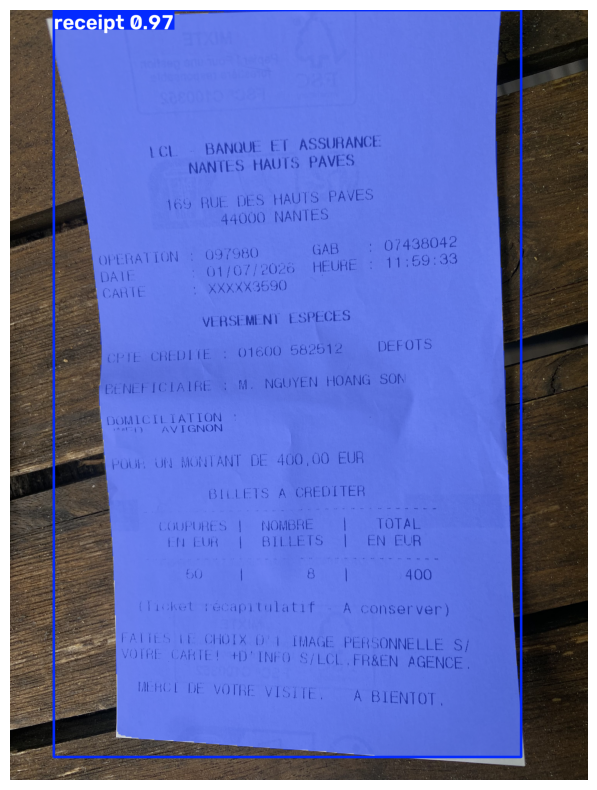

Processing image: /Users/son/Documents/my_ORC/Receipt_Understanding/sample_data/doc_seg/seg_1.jpg

image 1/1 /Users/son/Documents/my_ORC/Receipt_Understanding/sample_data/doc_seg/seg_1.jpg: 640x640 1 receipt, 59.3ms
Speed: 2.9ms preprocess, 59.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
1 results found


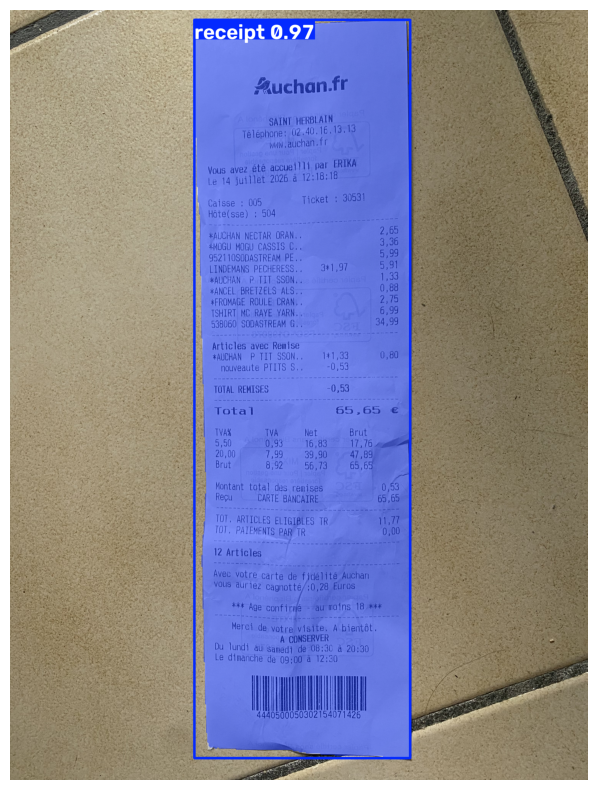

In [10]:
test_img = ROOT_DIR / 'sample_data/doc_seg/seg_2.jpg'
test_img = list(ROOT_DIR.glob('sample_data/doc_seg/*.jpg'))
if not isinstance(test_img, list):
    test_img = [test_img]
# Run the model on the test image and plot the results
# The model is YOLO26 so it has NMS free end-to-end-prediction (overrides with end2end=False to use NMS)
## end2end=False: Setting it to False lets you run prediction using the traditional NMS pipeline
## iou=0.4: Intersection Over Union (IoU) threshold for Non-Maximum Suppression (NMS)
## rect=False: If True, use minimum-rectangle padding when possible, avoid when images in batch have different sizes
for img in test_img:
    print(f"Processing image: {img}")
    results = model.predict(
        source=img, 
        end2end=False, 
        iou=0.4, 
        rect=False,
        conf=0.25)
    print(len(results), "results found")
    for result in results:
        plot_seg_result(result, details=False)